In [78]:
import copy
import datetime as dt
from datetime import datetime
import importlib  # needed so that we can reload packages
import logging
import os
import pathlib
import sys
import time
import warnings
from typing import Union, Tuple
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from utils.logger_utils import setup_clean_logger, mute_external_loggers

# SISEPUEDE imports
from sisepuede.manager.sisepuede_examples import SISEPUEDEExamples
from sisepuede.manager.sisepuede_file_structure import SISEPUEDEFileStructure
import sisepuede.core.support_classes as sc
import sisepuede.transformers as trf
import sisepuede.utilities._plotting as spu
import sisepuede.utilities._toolbox as sf
import sisepuede.core.attribute_table as att
import sisepuede.manager.sisepuede_examples as sxl
import sisepuede.manager.sisepuede_file_structure as sfs
import sisepuede.visualization.plots as svp

# --- Runtime configuration ---
warnings.filterwarnings("ignore")

# Set up a clean logger for your notebook
logger = setup_clean_logger("notebook", logging.INFO)
logger.info("Notebook started successfully.")

# Mute logs from sisepuede to avoid duplication
mute_external_loggers(["sisepuede"])

2026-03-25 12:48:11,875 - INFO - Notebook started successfully.


In [79]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Initial Set up

Make sure to edit the config yaml under ssp_modeling/config_files/config.yaml


In [80]:
# Set up dir paths

CURR_DIR_PATH = pathlib.Path(os.getcwd())
SSP_MODELING_DIR_PATH = CURR_DIR_PATH.parent
PROJECT_DIR_PATH = SSP_MODELING_DIR_PATH.parent
DATA_DIR_PATH = SSP_MODELING_DIR_PATH.joinpath("input_data")
RUN_OUTPUT_DIR_PATH = SSP_MODELING_DIR_PATH.joinpath("ssp_run_output")
CONFIG_DIR_PATH = CURR_DIR_PATH.joinpath("config_files")

In [81]:
from ssp_transformations_handler.GeneralUtils import GeneralUtils

# Initialize general utilities
g_utils = GeneralUtils()

In [82]:
# Load config file
YAML_FILE_PATH = os.path.join(CONFIG_DIR_PATH, "config.yaml")
config_params = g_utils.read_yaml(YAML_FILE_PATH)

country_name = config_params['country_name']
sim_end_year = config_params.get('sim_end_year', 2050)

logger.info(f"Country name: {country_name}")
logger.info(f"Simulation end year: {sim_end_year}")

2026-03-25 12:48:11,933 - INFO - Country name: libya
2026-03-25 12:48:11,933 - INFO - Simulation end year: 2050


In [83]:
def get_file_structure(
    y0: int = 2015,
    y1: int = sim_end_year,
) -> Tuple[sfs.SISEPUEDEFileStructure, att.AttributeTable]:
    """Get the SISEPUEDE File Structure and update the attribute table
        with new years.
    """
    file_struct = sfs.SISEPUEDEFileStructure(
        initialize_directories = False,
    )
 
    key_time_period = file_struct.model_attributes.dim_time_period
    key_year = file_struct.model_attributes.field_dim_year

    years = np.arange(y0, y1 + 1, ).astype(int)
    attribute_time_period = att.AttributeTable(
        pd.DataFrame(
            {
                key_time_period: range(len(years)),
                key_year: years,
            }
        ),
        key_time_period,
    )
 
    (
        file_struct
        .model_attributes
        .update_dimensional_attribute_table(
            attribute_time_period,
        )
    )
 
    return (file_struct, attribute_time_period, )


In [84]:
# Set up model attributes (needed for subsector fields and color maps)
_FILE_STRUCTURE, _ATTRIBUTE_TABLE_TIME_PERIOD = get_file_structure(y1=sim_end_year)
matt = _FILE_STRUCTURE.model_attributes
regions = sc.Regions(matt, )

## Load specific run outputs

Reading directly from the run folder — no model execution needed.

In [85]:
# ── Define run to analyze ─────────────────────────────────────────────────────
RUN_ID = "sisepuede_results_sisepuede_run_2026-03-24T21;46;12.697431"
RUN_FOLDER_NAME = f"{RUN_ID}"
RUN_ID_OUTPUT_DIR_PATH = RUN_OUTPUT_DIR_PATH / RUN_FOLDER_NAME

print(f"Run folder: {RUN_ID_OUTPUT_DIR_PATH}")
print(f"Exists: {RUN_ID_OUTPUT_DIR_PATH.exists()}")

Run folder: /Users/fabianfuentes/git/ssp_libya/ssp_modeling/ssp_run_output/sisepuede_results_sisepuede_run_2026-03-24T21;46;12.697431
Exists: True


In [86]:
# ── Read attribute tables ─────────────────────────────────────────────────────
att_primary  = pd.read_csv(RUN_ID_OUTPUT_DIR_PATH / "ATTRIBUTE_PRIMARY.csv")
att_strategy = pd.read_csv(RUN_ID_OUTPUT_DIR_PATH / "ATTRIBUTE_STRATEGY.csv")

print(f"att_primary  shape: {att_primary.shape}")
print(f"att_strategy shape: {att_strategy.shape}")
display(att_primary.head())
display(att_strategy)

att_primary  shape: (69, 4)
att_strategy shape: (144, 6)


,primary_id,design_id,strategy_id,future_id
0,0,0,0,0
1,1001,0,1000,0
2,2002,0,1001,0
3,3003,0,1002,0
4,4004,0,1003,0


,strategy_id,strategy_code,strategy,description,transformation_specification,baseline_strategy_id
0,0,BASE,Strategy TX:BASE,NaN,TX:BASE,1
1,1000,AGRC:DEC_CH4_RICE,Singleton - Default Value - AGRC: Improve rice...,NaN,TX:AGRC:DEC_CH4_RICE,0
2,1001,AGRC:DEC_EXPORTS,Singleton - Default Value - AGRC: Decrease Exp...,NaN,TX:AGRC:DEC_EXPORTS,0
3,1002,AGRC:DEC_LOSSES_SUPPLY_CHAIN,Singleton - Default Value - AGRC: Reduce suppl...,NaN,TX:AGRC:DEC_LOSSES_SUPPLY_CHAIN,0
4,1003,AGRC:INC_CONSERVATION_AGRICULTURE,Singleton - Default Value - AGRC: Expand conse...,NaN,TX:AGRC:INC_CONSERVATION_AGRICULTURE,0
...,...,...,...,...,...,...
139,6068,WHIRLPOOL:TX:WASO:INC_CAPTURE_BIOGAS,Remove TX:WASO:INC_CAPTURE_BIOGAS from All Act...,NaN,TX:AGRC:DEC_CH4_RICE|TX:AGRC:DEC_EXPORTS|TX:AG...,0
140,6069,WHIRLPOOL:TX:WASO:INC_ENERGY_FROM_BIOGAS,Remove TX:WASO:INC_ENERGY_FROM_BIOGAS from All...,NaN,TX:AGRC:DEC_CH4_RICE|TX:AGRC:DEC_EXPORTS|TX:AG...,0
141,6070,WHIRLPOOL:TX:WASO:INC_ENERGY_FROM_INCINERATION,Remove TX:WASO:INC_ENERGY_FROM_INCINERATION fr...,NaN,TX:AGRC:DEC_CH4_RICE|TX:AGRC:DEC_EXPORTS|TX:AG...,0
142,6071,WHIRLPOOL:TX:WASO:INC_LANDFILLING,Remove TX:WASO:INC_LANDFILLING from All Actions,NaN,TX:AGRC:DEC_CH4_RICE|TX:AGRC:DEC_EXPORTS|TX:AG...,0


In [87]:
# ── Parse strategy metadata from strategy_code and strategy columns ──────────
#
# strategy_code patterns:
#   Singleton  : "AGRC:DEC_CH4_RICE"             → sector=AGRC, transformation_code=DEC_CH4_RICE
#   WHIRLPOOL  : "WHIRLPOOL:TX:AGRC:DEC_CH4_RICE" → sector=AGRC, transformation_code=DEC_CH4_RICE
#   Composite  : "AF:ALL"                        → sector=AF,   transformation_code=ALL
#   BASE       : "BASE"                          → NaN
#
# strategy text pattern (for singletons):
#   "Singleton - Default Value - AGRC: Improve rice management"

# sector + transformation_code from strategy_code (supports digits like DEC_CH4_RICE)
att_strategy['sector'] = (
    att_strategy['strategy_code']
    .str.extract(r'(?:WHIRLPOOL:TX:)?([A-Z]+):[A-Z0-9_]+$', expand=False)
)

att_strategy['transformation_code'] = (
    att_strategy['strategy_code']
    .str.extract(r':([A-Z0-9_]+)$', expand=False)
)

# transformation_name from the strategy description text
att_strategy['transformation_name'] = (
    att_strategy['strategy']
    .str.extract(r'-\s*[A-Z]+:\s*(.+)$', expand=False)
)

# combined field: "AGRC: Improve rice management"
att_strategy['transformation_name_sector'] = (
    att_strategy['sector'].fillna('')
    + ': '
    + att_strategy['transformation_name'].fillna('')
).where(att_strategy['transformation_name'].notna())

display(att_strategy[['strategy_id','strategy_code','sector','transformation_code',
                        'transformation_name','transformation_name_sector']])

,strategy_id,strategy_code,sector,transformation_code,transformation_name,transformation_name_sector
0,0,BASE,NaN,NaN,NaN,NaN
1,1000,AGRC:DEC_CH4_RICE,AGRC,DEC_CH4_RICE,Improve rice management,AGRC: Improve rice management
2,1001,AGRC:DEC_EXPORTS,AGRC,DEC_EXPORTS,Decrease Exports,AGRC: Decrease Exports
3,1002,AGRC:DEC_LOSSES_SUPPLY_CHAIN,AGRC,DEC_LOSSES_SUPPLY_CHAIN,Reduce supply chain losses,AGRC: Reduce supply chain losses
4,1003,AGRC:INC_CONSERVATION_AGRICULTURE,AGRC,INC_CONSERVATION_AGRICULTURE,Expand conservation agriculture,AGRC: Expand conservation agriculture
...,...,...,...,...,...,...
139,6068,WHIRLPOOL:TX:WASO:INC_CAPTURE_BIOGAS,WASO,INC_CAPTURE_BIOGAS,NaN,NaN
140,6069,WHIRLPOOL:TX:WASO:INC_ENERGY_FROM_BIOGAS,WASO,INC_ENERGY_FROM_BIOGAS,NaN,NaN
141,6070,WHIRLPOOL:TX:WASO:INC_ENERGY_FROM_INCINERATION,WASO,INC_ENERGY_FROM_INCINERATION,NaN,NaN
142,6071,WHIRLPOOL:TX:WASO:INC_LANDFILLING,WASO,INC_LANDFILLING,NaN,NaN


In [88]:
# ── Read wide inputs/outputs CSV ──────────────────────────────────────────────
_wide_csv = list(RUN_ID_OUTPUT_DIR_PATH.glob("*_WIDE_INPUTS_OUTPUTS.csv"))
assert _wide_csv, f"No se encontró archivo WIDE en {RUN_ID_OUTPUT_DIR_PATH}"

df_export = pd.read_csv(_wide_csv[0])
KEY_PRIMARY = "primary_id"

# Filter to keep only primary_id 0 (baseline) and 2002 (strategy 2)
df_export = df_export[df_export[KEY_PRIMARY].isin([0, 1001,2002, 3003, 4004])]

print(f"df_export shape: {df_export.shape}")
df_export[[KEY_PRIMARY, 'region', 'time_period']].drop_duplicates().head(10)

df_export shape: (180, 4054)


,primary_id,region,time_period
0,0,libya,0
1,0,libya,1
2,0,libya,2
3,0,libya,3
4,0,libya,4
5,0,libya,5
6,0,libya,6
7,0,libya,7
8,0,libya,8
9,0,libya,9


## Emissions Stack Plots

In [89]:
def plot_field_stack(
    df,
    fields,
    dict_format,
    time_col="time_period",
    primary_id=0,
    figsize=(18, 8),
    legend_loc='upper right',
    legend_bbox=(1.1, 1),
    ylabel="MT Emissions CO2e",
    xlabel="Time Period",
    title=None,
):
    """
    Plots a stack plot of the selected fields for a given primary_id.

    Args:
        df (pd.DataFrame): DataFrame containing output data.
        fields (list): List of column names to plot.
        dict_format (dict): Formatting dictionary for colors.
        time_col (str): Name of the time column.
        primary_id (int): Value of primary_id to filter.
        figsize (tuple): Figure size.
        legend_loc (str): Legend location.
        legend_bbox (tuple): Legend bbox_to_anchor.
        ylabel (str): Y-axis label.
        xlabel (str): X-axis label.
        title (str): Plot title.
    """
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if title:
        ax.set_title(title)

    df_plot = df[df[KEY_PRIMARY].isin([primary_id])]

    fig, ax = spu.plot_stack(
        df_plot,
        fields,
        dict_formatting=dict_format,
        field_x=time_col,
        figtuple=(fig, ax),
    )

    ax.legend(loc=legend_loc, bbox_to_anchor=legend_bbox, title="Fields")
    plt.show()

In [90]:
# Define the fields to plot and the formatting dictionary
subsector_emission_fields = matt.get_all_subsector_emission_total_fields()

dict_format = dict(
    (k, {"color": v}) for (k, v) in
    matt.get_subsector_color_map().items()
)

In [91]:
primary_ids_to_plot = df_export[KEY_PRIMARY].unique()

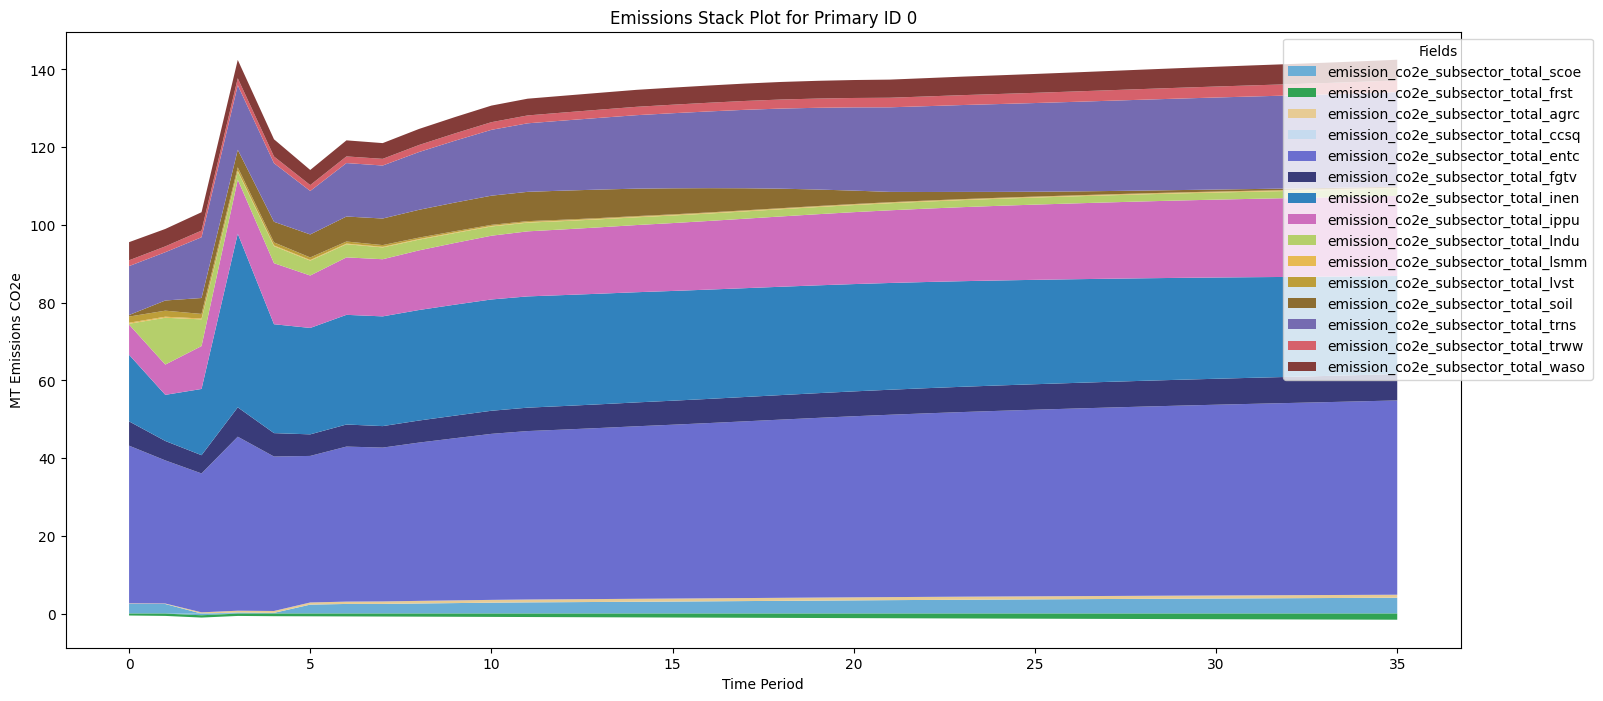

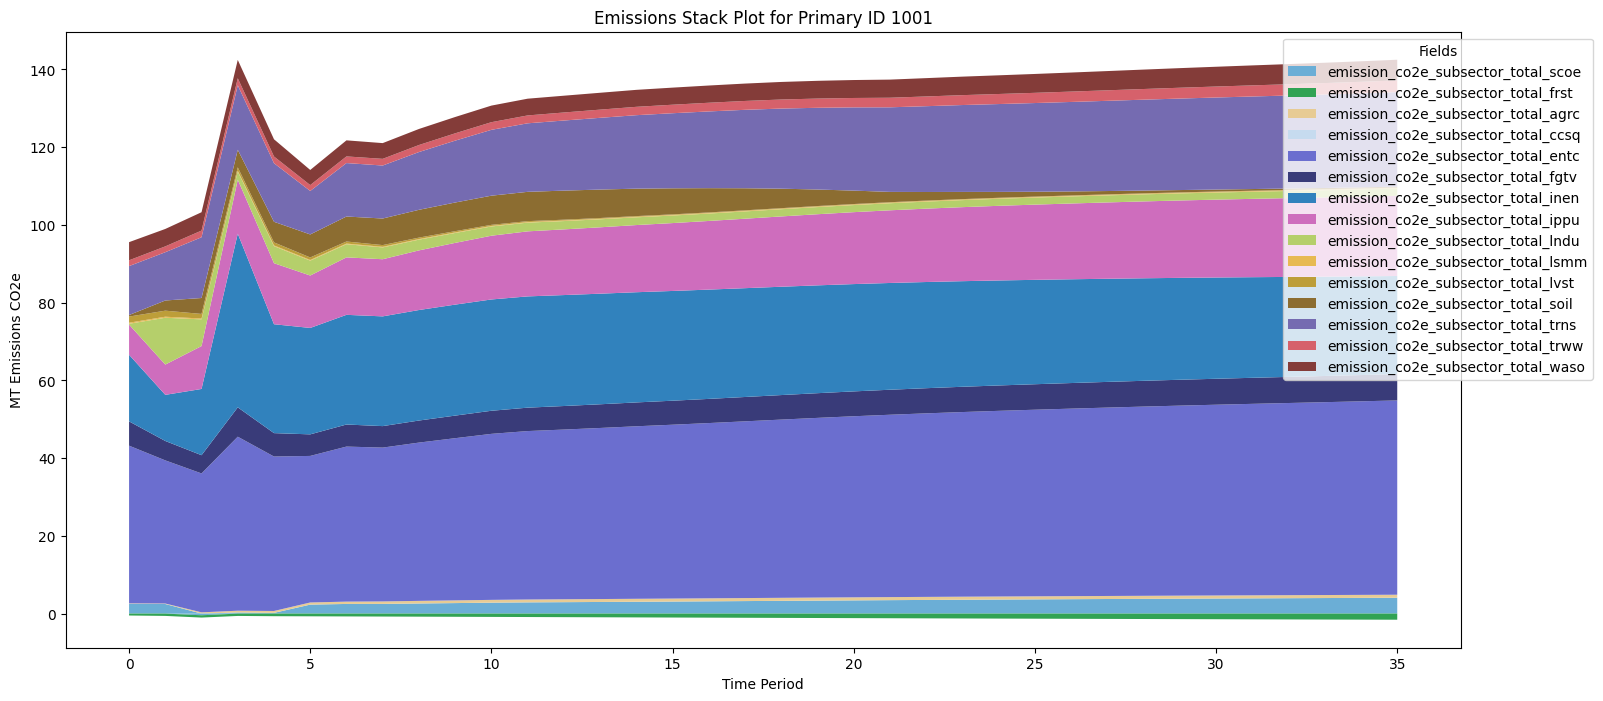

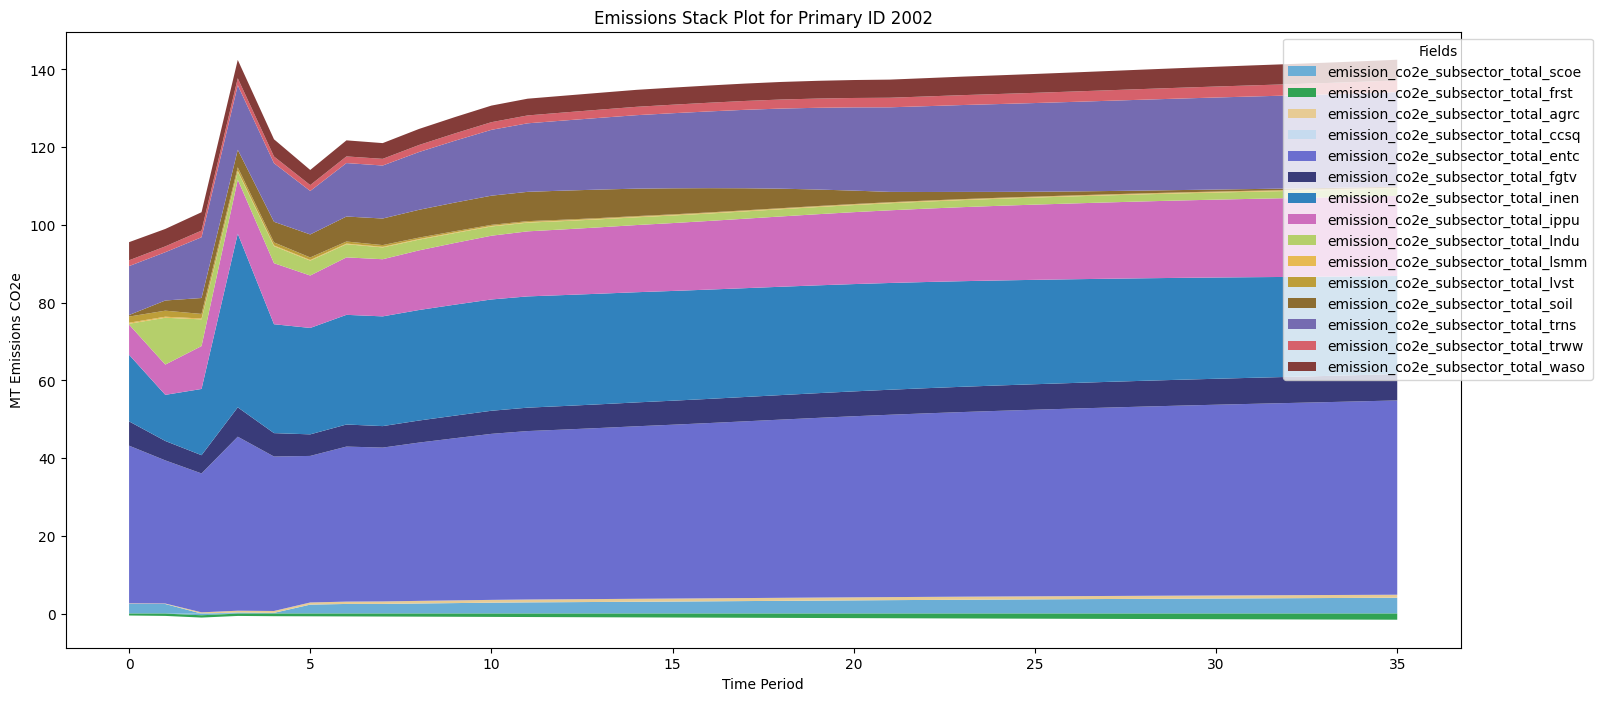

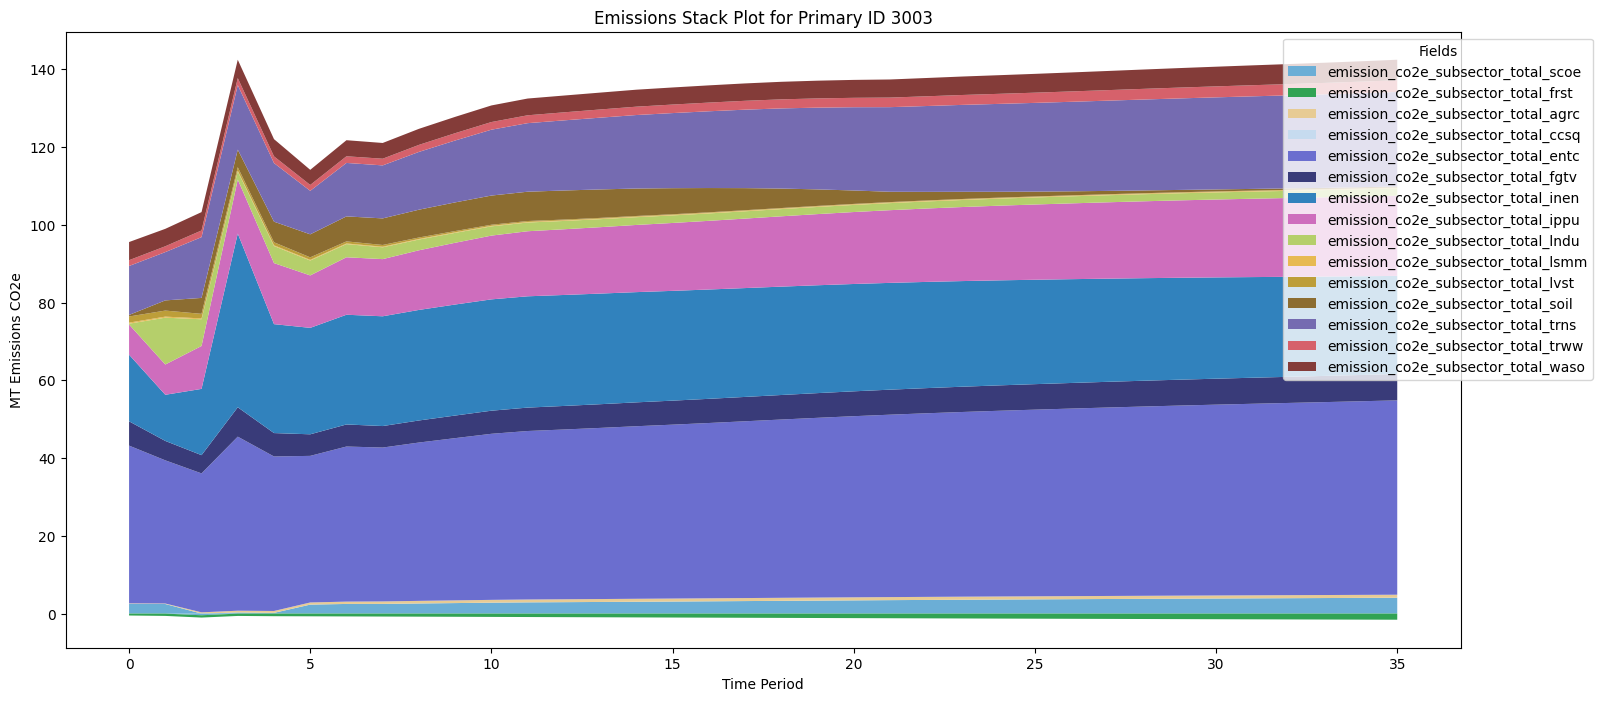

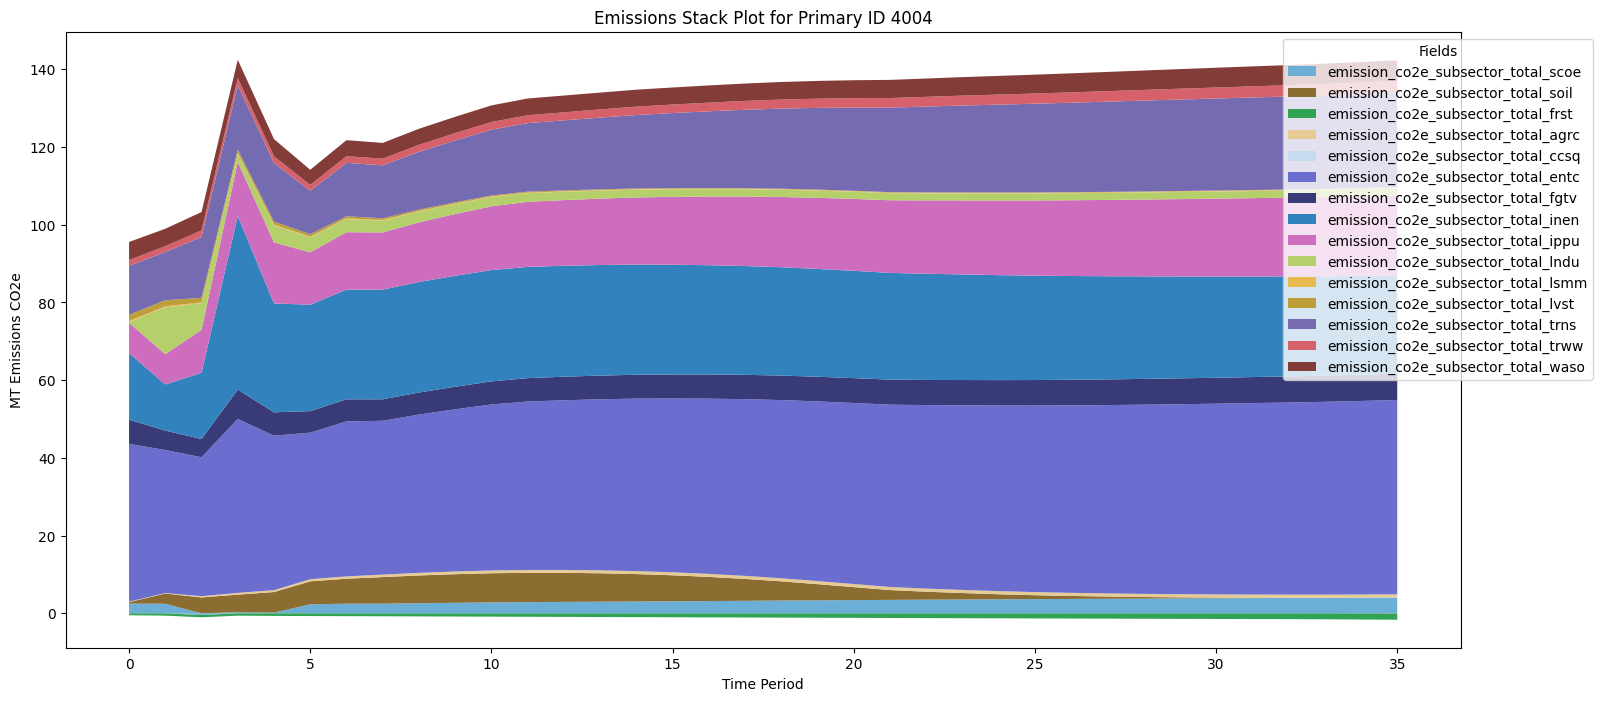

In [92]:
# Plot the emissions stack for each primary_id
for primary_id in primary_ids_to_plot:

    plot_field_stack(
        df_export,
        subsector_emission_fields,
        dict_format,
        primary_id=primary_id,
        title=f"Emissions Stack Plot for Primary ID {primary_id}"
    )

## Post-procesamiento: Intertemporal Decomposition (rescaling)


In [93]:
import sys
sys.path.insert(0, str(PROJECT_DIR_PATH))

from ssp_modeling.output_postprocessing.intertemporal_decomposition import (
    run_postprocessing,
    prepare_targets,
    preprocess_ssp_output,
    rescale,
)
print("Módulo de post-procesamiento cargado correctamente.")

Módulo de post-procesamiento cargado correctamente.


In [94]:
# ── Parámetros ────────────────────────────────────────────────────────────────
TARGETS_PATH = PROJECT_DIR_PATH / "ssp_modeling/output_postprocessing/data/invent/emission_targets_lby_2023.csv"
ISO_CODE3    = "LBY"
YEAR_REF     = 2023
REGION       = country_name          # "libya"  ← viene del config.yaml

# Ruta donde guardar el CSV resultante (None = no escribir)
OUTPUT_PATH  = Path(RUN_ID_OUTPUT_DIR_PATH) / "decomposed_ssp_output_py.csv"

print(f"Targets  : {TARGETS_PATH}")
print(f"ISO code : {ISO_CODE3}")
print(f"Year ref : {YEAR_REF}")
print(f"Region   : {REGION}")
print(f"Output   : {OUTPUT_PATH}")

Targets  : /Users/fabianfuentes/git/ssp_libya/ssp_modeling/output_postprocessing/data/invent/emission_targets_lby_2023.csv
ISO code : LBY
Year ref : 2023
Region   : libya
Output   : /Users/fabianfuentes/git/ssp_libya/ssp_modeling/ssp_run_output/sisepuede_results_sisepuede_run_2026-03-24T21;46;12.697431/decomposed_ssp_output_py.csv


In [95]:
# ── Ejecutar rescaling ────────────────────────────────────────────────────────
df_decomposed = run_postprocessing(
    df_ssp_output         = df_export,
    targets_path          = TARGETS_PATH,
    iso_code3             = ISO_CODE3,
    year_ref              = YEAR_REF,
    region                = REGION,
    initial_conditions_id = "_0",
    output_path           = OUTPUT_PATH,
)

print(f"\nResultado: {df_decomposed.shape[0]} filas × {df_decomposed.shape[1]} columnas")
df_decomposed.head(3)

Changed 5 zero(s) in: emission_co2e_ch4_entc_generation_pp_biomass (time_period == 8)
Changed 5 zero(s) in: emission_co2e_ch4_entc_generation_pp_coal (time_period == 8)
Changed 5 zero(s) in: emission_co2e_ch4_entc_generation_pp_coal_ccs (time_period == 8)
Changed 5 zero(s) in: emission_co2e_ch4_entc_generation_pp_gas_ccs (time_period == 8)
Changed 5 zero(s) in: emission_co2e_ch4_entc_generation_pp_geothermal (time_period == 8)
Changed 5 zero(s) in: emission_co2e_ch4_entc_generation_pp_hydropower (time_period == 8)
Changed 5 zero(s) in: emission_co2e_ch4_entc_generation_pp_nuclear (time_period == 8)
Changed 5 zero(s) in: emission_co2e_ch4_entc_generation_pp_ocean (time_period == 8)
Changed 5 zero(s) in: emission_co2e_ch4_entc_generation_pp_solar (time_period == 8)
Changed 5 zero(s) in: emission_co2e_ch4_entc_generation_pp_wind (time_period == 8)
Changed 5 zero(s) in: emission_co2e_co2_entc_generation_pp_coal (time_period == 8)
Changed 5 zero(s) in: emission_co2e_co2_entc_generation_pp_c

,primary_id,region,time_period,area_agrc_crops_bevs_and_spices,area_agrc_crops_cereals,area_agrc_crops_fibers,area_agrc_crops_fruits,area_agrc_crops_herbs_and_other_perennial_crops,area_agrc_crops_nuts,area_agrc_crops_other_annual,...,yf_agrc_herbs_and_other_perennial_crops_tonne_ha,yf_agrc_nuts_tonne_ha,yf_agrc_other_annual_tonne_ha,yf_agrc_other_woody_perennial_tonne_ha,yf_agrc_pulses_tonne_ha,yf_agrc_rice_tonne_ha,yf_agrc_sugar_cane_tonne_ha,yf_agrc_tubers_tonne_ha,yf_agrc_vegetables_and_vines_tonne_ha,yf_lndu_supremum_pastures_tonne_per_ha
0,0,libya,8,0.0,4.035087e+06,0.0,3.088256e+06,0.0,737827.582324,2.579297e+06,...,2.0,0.5,0.0,0.0,0.5,0.0,0.0,17.0,20.0,92.81
1,0,libya,9,0.0,4.186683e+06,0.0,3.204280e+06,0.0,765547.399674,2.676199e+06,...,2.0,0.5,0.0,0.0,0.5,0.0,0.0,17.0,20.0,92.81
2,0,libya,10,0.0,4.306798e+06,0.0,3.296210e+06,0.0,787510.787871,2.752979e+06,...,2.0,0.5,0.0,0.0,0.5,0.0,0.0,17.0,20.0,92.81


### Tests de validación

Compara los resultados Python con el CSV que generó el script R.
Si el CSV de R no existe, se corren validaciones internas de consistencia.

## Costos y Beneficios

Corre el pipeline de costos y beneficios sobre `df_decomposed` (ya en memoria).
Equivalente a `ssp_modeling/cost-benefits/cb.ipynb` pero sin escribir CSVs intermedios.

In [96]:
import sys
sys.path.insert(0, str(PROJECT_DIR_PATH / 'ssp_modeling' / 'cost-benefits'))
from costs_benefits_ssp.cb_calculate import CostBenefits

CB_CONFIG_PATH = PROJECT_DIR_PATH / 'ssp_modeling' / 'cost-benefits' / 'cb_config_files' / 'cb_config_params.xlsx'
CB_OUTPUT_PATH = PROJECT_DIR_PATH / 'ssp_modeling' / 'cost-benefits' / 'out'
CB_OUTPUT_PATH.mkdir(exist_ok=True)

print(f'att_primary : {att_primary.shape}')
print(f'att_strategy: {att_strategy.shape}')

att_primary : (69, 4)
att_strategy: (144, 10)


In [97]:
#Strategy baaleline to CBA
strategy_code_base = 'BASE'
if strategy_code_base not in att_strategy['strategy_code'].values:
    raise ValueError(f"Base strategy '{strategy_code_base}' no encontrada en att_strategy")

# Usa df_decomposed que ya está en memoria (resultado del rescaling)
cb = CostBenefits(df_decomposed, att_primary, att_strategy, strategy_code_base)
cb.load_cb_parameters(str(CB_CONFIG_PATH))


The TX TX:FRST:INCREASE_SEQUESTRATION is missing on AttTransformationCode
The TX TX:LNDU:BOUND_CLASSES is missing on AttTransformationCode
The TX TX:LNDU:DEC_CLASS_LOSS is missing on AttTransformationCode
The TX TX:FRST:INCREASE_SEQUESTRATION is missing on AttTransformationCode
The TX TX:LNDU:BOUND_CLASSES is missing on AttTransformationCode
The TX TX:LNDU:DEC_CLASS_LOSS is missing on AttTransformationCode
The TX TX:ENFU:ADJ_EXPORTS is missing on AttTransformationCode
The TX TX:SCOE:INC_EFFICIENCY_HEAT is missing on AttTransformationCode
The TX TX:ENFU:ADJ_EXPORTS is missing on AttTransformationCode
The TX TX:SCOE:INC_EFFICIENCY_HEAT is missing on AttTransformationCode
The TX TX:ENFU:ADJ_EXPORTS is missing on AttTransformationCode
The TX TX:FRST:INCREASE_SEQUESTRATION is missing on AttTransformationCode
The TX TX:LNDU:BOUND_CLASSES is missing on AttTransformationCode
The TX TX:LNDU:DEC_CLASS_LOSS is missing on AttTransformationCode
The TX TX:SCOE:INC_EFFICIENCY_HEAT is missing on AttTr

In [98]:
results_system = cb.compute_system_cost_for_all_strategies(verbose=False)


************************************
*Strategy : AGRC:DEC_CH4_RICE (0/4)
************************************


************************************
*Strategy : AGRC:DEC_EXPORTS (1/4)
************************************


************************************
*Strategy : AGRC:DEC_LOSSES_SUPPLY_CHAIN (2/4)
************************************


************************************
*Strategy : AGRC:INC_CONSERVATION_AGRICULTURE (3/4)
************************************



In [99]:
results_tx = cb.compute_technical_cost_for_all_strategies(verbose=False)


************************************
*Strategy : AGRC:DEC_CH4_RICE (0/4)
************************************

La variable se evalúa en Transformation Cost

************************************
*Strategy : AGRC:DEC_EXPORTS (1/4)
************************************

The Strategy AGRC:DEC_EXPORTS hasn't technical costs

************************************
*Strategy : AGRC:DEC_LOSSES_SUPPLY_CHAIN (2/4)
************************************

La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost

************************************
*Strategy : AGRC:INC_CONSERVATION_AGRICULTURE (3/4)
************************************

La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost


In [100]:
results_all    = pd.concat([results_system, results_tx], ignore_index=True)

results_all_pp         = cb.cb_process_interactions(results_all)
results_all_pp_shifted = cb.cb_shift_costs(results_all_pp)

print(f'results_all_pp_shifted: {results_all_pp_shifted.shape}')
results_all_pp_shifted.head(3)

Resolving Interactions in SCOE :  
No interactions, skipping... AGRC:DEC_CH4_RICE
Resolving Interactions in INEN :  
No interactions, skipping... AGRC:DEC_CH4_RICE
Resolving Interactions in SCOE :  
No interactions, skipping... AGRC:DEC_EXPORTS
Resolving Interactions in INEN :  
No interactions, skipping... AGRC:DEC_EXPORTS
Resolving Interactions in SCOE :  
No interactions, skipping... AGRC:DEC_LOSSES_SUPPLY_CHAIN
Resolving Interactions in INEN :  
No interactions, skipping... AGRC:DEC_LOSSES_SUPPLY_CHAIN
Resolving Interactions in SCOE :  
No interactions, skipping... AGRC:INC_CONSERVATION_AGRICULTURE
Resolving Interactions in INEN :  
No interactions, skipping... AGRC:INC_CONSERVATION_AGRICULTURE
results_all_pp_shifted: (20070, 10)


,strategy_code,future_id,region,time_period,difference_variable,variable_value_baseline,variable_value_pathway,difference_value,variable,value
0,AGRC:DEC_CH4_RICE,0,libya,8,yield_agrc_bevs_and_spices_tonne,0.0,0.0,0.0,cb:agrc:crop_value:crops_produced:bevs_and_spices,0.0
1,AGRC:DEC_CH4_RICE,0,libya,9,yield_agrc_bevs_and_spices_tonne,0.0,0.0,0.0,cb:agrc:crop_value:crops_produced:bevs_and_spices,0.0
2,AGRC:DEC_CH4_RICE,0,libya,10,yield_agrc_bevs_and_spices_tonne,0.0,0.0,0.0,cb:agrc:crop_value:crops_produced:bevs_and_spices,0.0


In [101]:
# ── Reshape para análisis / Tableau ──────────────────────────────────
cb_data = results_all_pp_shifted.copy()

# Split variable en partes (name:sector:cb_type:item_1:item_2)
cb_chars = cb_data['variable'].astype(str).str.split(':', n=4, expand=True)
cb_chars.columns = ['name', 'sector', 'cb_type', 'item_1', 'item_2']
cb_data = pd.concat([cb_data, cb_chars], axis=1)

# Escalar de USD a billones (B USD)
cb_data['value'] = cb_data['value'] / 1e9
cb_data['variable_value_baseline'] = cb_data['variable_value_baseline'] / 1e9
cb_data['variable_value_pathway'] = cb_data['variable_value_pathway'] / 1e9

# Eliminar filas 'shifted'
cb_data = cb_data[~cb_data['item_2'].astype(str).str.contains('shifted', na=False)]
cb_data = cb_data[~cb_data['variable'].astype(str).str.contains('shifted2', na=False)]

# Año calendario
cb_data['Year'] = cb_data['time_period'] + 2015

# ── Mapeos dinámicos desde att_strategy y att_primary ────────────────
strategy_id_map   = att_strategy.set_index('strategy_code')['strategy_id'].to_dict()
strategy_name_map = att_strategy.set_index('strategy_code')['strategy'].to_dict()

# primary_id por estrategia: une att_primary con att_strategy en strategy_id
primary_id_map = (
    att_strategy[['strategy_code', 'strategy_id']]
    .merge(att_primary[['primary_id', 'strategy_id']], on='strategy_id', how='left')
    .drop_duplicates('strategy_code')
    .set_index('strategy_code')['primary_id']
    .to_dict()
)

cb_data['strategy']    = cb_data['strategy_code'].astype(str).map(strategy_name_map).fillna(cb_data['strategy_code'])
cb_data['strategy_id'] = cb_data['strategy_code'].astype(str).map(strategy_id_map)
cb_data['primary_id']  = cb_data['strategy_code'].astype(str).map(primary_id_map)

# IDs compuestos
cb_data['ids'] = cb_data['variable'].astype(str) + ':' + cb_data['strategy_id'].astype(str)

# Corregir signo capex electricidad (debe ser negativo = inversión)
mask_entc = cb_data['variable'].astype(str).str.contains('cb:entc:technical_cost:electricity:capex', na=False)
cb_data.loc[mask_entc, 'value'] = -cb_data.loc[mask_entc, 'value'].abs()

# Merge GDP
gdp = df_decomposed[['primary_id', 'time_period', 'gdp_mmm_usd']].copy()
cb_data = cb_data.merge(gdp, on=['primary_id', 'time_period'], how='left')

print(f'cb_data: {cb_data.shape}   NaNs en value: {cb_data["value"].isna().sum()}')
cb_data.head(3)

cb_data: (18732, 21)   NaNs en value: 0


,strategy_code,future_id,region,time_period,difference_variable,variable_value_baseline,variable_value_pathway,difference_value,variable,value,...,sector,cb_type,item_1,item_2,Year,strategy,strategy_id,primary_id,ids,gdp_mmm_usd
0,AGRC:DEC_CH4_RICE,0,libya,8,yield_agrc_bevs_and_spices_tonne,0.0,0.0,0.0,cb:agrc:crop_value:crops_produced:bevs_and_spices,0.0,...,agrc,crop_value,crops_produced,bevs_and_spices,2023,Singleton - Default Value - AGRC: Improve rice...,1000,1001.0,cb:agrc:crop_value:crops_produced:bevs_and_spi...,148.556382
1,AGRC:DEC_CH4_RICE,0,libya,9,yield_agrc_bevs_and_spices_tonne,0.0,0.0,0.0,cb:agrc:crop_value:crops_produced:bevs_and_spices,0.0,...,agrc,crop_value,crops_produced,bevs_and_spices,2024,Singleton - Default Value - AGRC: Improve rice...,1000,1001.0,cb:agrc:crop_value:crops_produced:bevs_and_spi...,160.191317
2,AGRC:DEC_CH4_RICE,0,libya,10,yield_agrc_bevs_and_spices_tonne,0.0,0.0,0.0,cb:agrc:crop_value:crops_produced:bevs_and_spices,0.0,...,agrc,crop_value,crops_produced,bevs_and_spices,2025,Singleton - Default Value - AGRC: Improve rice...,1000,1001.0,cb:agrc:crop_value:crops_produced:bevs_and_spi...,171.318206


In [102]:
# cb_data.to_csv(Path(RUN_ID_OUTPUT_DIR_PATH) / "cost_benefits_data_for_analysis.csv", index=False, encoding="UTF-8")

In [103]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np

# ── 1. Filtrar: solo filas con al menos un valor no-cero (baseline o pathway) ──
df_viz = cb_data[
    (cb_data['variable_value_baseline'] != 0) | (cb_data['variable_value_pathway'] != 0)
].copy()

# ── 2. Agregar por (cb_type, difference_variable, strategy_id, Year) ───────────
agg = (
    df_viz
    .groupby(['cb_type', 'difference_variable', 'strategy_id', 'Year'], dropna=False)[
        ['variable_value_baseline', 'variable_value_pathway']
    ]
    .sum()
    .reset_index()
)

# Mantener solo combos (cb_type, difference_variable) que sean != 0
# en TODOS los periodos (usamos la lógica del análisis anterior)
all_years = set(agg['Year'].unique())
nonzero_check = (
    agg.groupby(['cb_type', 'difference_variable', 'strategy_id'])
    .apply(lambda g: (g['variable_value_baseline'] != 0).all() or (g['variable_value_pathway'] != 0).all())
    .reset_index(name='always_nonzero')
)
valid_combos = nonzero_check[nonzero_check['always_nonzero']][['cb_type', 'difference_variable', 'strategy_id']]
agg = agg.merge(valid_combos, on=['cb_type', 'difference_variable', 'strategy_id'], how='inner')

cb_types = sorted(agg['cb_type'].dropna().unique())
strategy_ids = sorted(agg['strategy_id'].dropna().unique())

print(f"cb_types activos   : {cb_types}")
print(f"strategy_ids únicos: {strategy_ids}")
print(f"Filas en agg       : {len(agg)}")

cb_types activos   : ['air_pollution', 'congestion', 'consumer_savings', 'crop_value', 'ecosystem_services', 'env_pollution', 'fuel_cost', 'human_health', 'ippu_value', 'land_pollution', 'lvst_value', 'road_safety', 'sector_specific', 'system_cost', 'technical_cost', 'technical_savings', 'water_pollution']
strategy_ids únicos: [np.int64(1000), np.int64(1001), np.int64(1002), np.int64(1003)]
Filas en agg       : 14330


In [104]:
# ── 3. Diferencia (value) por difference_variable en el tiempo ────────────────
CB_TYPE_FILTER = ['technical_cost']   # ← cambia aquí para incluir otros cb_types

PALETTE = [
    '#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd',
    '#8c564b','#e377c2','#7f7f7f','#bcbd22','#17becf',
]

# Agregar value por (strategy_id, difference_variable, Year)
agg_val = (
    cb_data[cb_data['cb_type'].isin(CB_TYPE_FILTER) & (cb_data['value'] != 0)]
    .groupby(['strategy_id', 'difference_variable', 'Year'], dropna=False)['value']
    .sum()
    .reset_index()
)

print(f'Filas en agg_val: {len(agg_val)}')
print(f'strategy_ids: {sorted(agg_val["strategy_id"].unique())}')
print(f'difference_variables: {sorted(agg_val["difference_variable"].dropna().unique())}')
display(agg_val.head(10))

for strat_id in sorted(agg_val['strategy_id'].unique()):
    sub = agg_val[agg_val['strategy_id'] == strat_id].copy()
    if sub.empty:
        continue

    strategy_label = cb_data.loc[cb_data['strategy_id'] == strat_id, 'strategy'].iloc[0]
    diff_vars = sorted(sub['difference_variable'].dropna().unique())

    fig = go.Figure()
    for i_dv, dv in enumerate(diff_vars):
        df_dv = sub[sub['difference_variable'] == dv].sort_values('Year')
        color = PALETTE[i_dv % len(PALETTE)]
        short_dv = dv if len(dv) <= 45 else dv[:42] + '...'
        fig.add_trace(go.Scatter(
            x=df_dv['Year'], y=df_dv['value'],
            mode='lines+markers',
            line=dict(color=color, width=2),
            marker=dict(size=5),
            name=short_dv,
            hovertemplate=f'<b>{dv}</b><br>value: %{{y:,.2f}}<br>Year: %{{x}}<extra></extra>',
        ))

    fig.add_hline(y=0, line=dict(color='black', dash='dash', width=1))
    fig.update_layout(
        title=dict(
            text=(
                f'<b>Strategy {int(strat_id)}: {strategy_label}</b><br>'
                f'<sup>cb_type: {", ".join(CB_TYPE_FILTER)} · value = pathway − baseline</sup>'
            ),
            x=0.5,
        ),
        xaxis_title='Year', xaxis=dict(tickformat='d'),
        yaxis_title='value',
        height=500, width=1100,
        legend=dict(orientation='v', x=1.01, y=1, font=dict(size=9)),
        hovermode='x unified',
    )
    fig.show()

Filas en agg_val: 200
strategy_ids: [np.int64(1002)]
difference_variables: ['gasrecovered_waso_biogas_anaerobic_tonne', 'nemomod_entc_discounted_capital_investment_pp_wind', 'prod_enfu_fuel_electricity_pj', 'qty_agrc_total_food_produced_lost_tonne', 'qty_waso_biogas_yard_tonne', 'qty_waso_compost_yard_tonne', 'qty_waso_incinerated_yard_tonne', 'qty_waso_msw_recovered_for_energy_incineration_tonne', 'qty_waso_open_dump_yard_tonne']


,strategy_id,difference_variable,Year,value
0,1002,gasrecovered_waso_biogas_anaerobic_tonne,2029,3.903720e-07
1,1002,gasrecovered_waso_biogas_anaerobic_tonne,2030,7.877437e-07
2,1002,gasrecovered_waso_biogas_anaerobic_tonne,2031,1.192065e-06
3,1002,gasrecovered_waso_biogas_anaerobic_tonne,2032,1.603286e-06
4,1002,gasrecovered_waso_biogas_anaerobic_tonne,2033,2.021338e-06
5,1002,gasrecovered_waso_biogas_anaerobic_tonne,2034,2.446144e-06
6,1002,gasrecovered_waso_biogas_anaerobic_tonne,2035,2.877619e-06
7,1002,gasrecovered_waso_biogas_anaerobic_tonne,2036,3.315675e-06
8,1002,gasrecovered_waso_biogas_anaerobic_tonne,2037,3.760236e-06
9,1002,gasrecovered_waso_biogas_anaerobic_tonne,2038,4.211235e-06


## MAC – Paso 1: Mapeo de emisiones reescaladas a categorías de inventario

Equivalente a `data_prep_new_mapping.r` aplicado sobre `df_decomposed`.

In [105]:
# ── 0. Dependencias ──────────────────────────────────────────────────────────
try:
    from statsmodels.tsa.filters.hp_filter import hpfilter as sm_hpfilter
    HAS_SM = True
except ImportError:
    HAS_SM = False
    print('AVISO: statsmodels no disponible. Instala con: pip install statsmodels')

INVENT_DIR = PROJECT_DIR_PATH / 'ssp_modeling/output_postprocessing/data/invent'

# ── 1. Mapping de inventario ─────────────────────────────────────────────────
mapping = pd.read_csv(INVENT_DIR / 'emission_targets_lby_2023.csv')
mapping = mapping.drop(columns=['id', ISO_CODE3], errors='ignore').reset_index(drop=False).rename(columns={'index':'row_idx'})
mapping['ids'] = mapping['row_idx'].astype(str) + ':' + mapping['subsector_ssp'].astype(str) + ':' + mapping['gas'].astype(str)

# ── 2. EDGAR histórico ───────────────────────────────────────────────────────
edgar = pd.read_csv(INVENT_DIR / 'invent_historic_lby.csv')
edgar = edgar[edgar['Code'] == ISO_CODE3].copy()
edgar['ID'] = edgar['subsector'].astype(str) + ':' + edgar['Gas'].astype(str)
year_cols = [c for c in edgar.columns if str(c).isdigit()]
edgar_long = edgar.melt(id_vars=['Code','sector','subsector','Gas','ID'],
                         value_vars=year_cols, var_name='year_str', value_name='value')
edgar_long['Year'] = edgar_long['year_str'].astype(int)
edgar_long = edgar_long.drop(columns=['year_str'])
for col in ['strategy_id','primary_id','design_id','future_id']:
    edgar_long[col] = float('nan')
edgar_long['strategy'] = 'Historical'
edgar_long['source']   = 'EDGAR'
edgar_long['Contry']   = REGION
edgar_max_year = int(edgar_long['Year'].max())

# ── 3. Mapear vars SSP a categorías de inventario ────────────────────────────
id_vars = ['region','time_period','primary_id']
data = df_decomposed[df_decomposed['region'] == REGION].copy()

rows_agg = []
for _, row in mapping.iterrows():
    tvars = [v.strip() for v in str(row['vars']).split(':') if v.strip() in data.columns]
    if len(tvars) > 1:
        agg_col = data[tvars].sum(axis=1)
    elif len(tvars) == 1:
        agg_col = data[tvars[0]]
    else:
        agg_col = pd.Series(0.0, index=data.index)
    tmp = data[id_vars].copy()
    tmp['ids']   = row['ids']
    tmp['value'] = agg_col.values
    rows_agg.append(tmp)

data_long = pd.concat(rows_agg, ignore_index=True)

# ── 4. Merge metadatos + agregación a nivel inventario ───────────────────────
meta = mapping[['ids','sector','subsector','gas','ID']].copy()
data_long = data_long.merge(meta, on='ids', how='left')

data_inv = (
    data_long
    .groupby(['primary_id','time_period','ID','sector','subsector'], dropna=False)['value']
    .sum()
    .reset_index()
)
data_inv['Year']   = data_inv['time_period'] + 2015
data_inv['Gas']    = data_inv['ID'].str.split(':').str[-1]
data_inv['Code']   = ISO_CODE3
data_inv['Contry'] = REGION
data_inv['source'] = 'SISEPUEDE'

# ── 5. Merge estrategias + filtrar años >= edgar_max_year ────────────────────
data_inv = data_inv.merge(att_primary[['primary_id','strategy_id','design_id','future_id']],
                           on='primary_id', how='left')
data_inv = data_inv.merge(att_strategy[['strategy_id','strategy']], on='strategy_id', how='left')
data_inv = data_inv[data_inv['Year'] >= edgar_max_year].copy()

# ── 6. Combinar SSP + EDGAR ──────────────────────────────────────────────────
shared = ['primary_id','strategy_id','design_id','future_id',
          'sector','subsector','Gas','ID','Year','value','Code','Contry','strategy','source']
emissions = pd.concat(
    [data_inv[[c for c in shared if c in data_inv.columns]],
     edgar_long[[c for c in shared if c in edgar_long.columns]]],
    ignore_index=True
)
emissions = emissions.sort_values(['strategy_id','sector','subsector','Gas','Year']).reset_index(drop=True)

print(f'emissions shape: {emissions.shape}')
print(f'Años SSP  : {sorted(data_inv["Year"].unique())}')
print(f'Estrategias: {emissions["strategy"].dropna().unique()}')
display(emissions.head(8))

emissions shape: (6006, 14)
Años SSP  : [np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026), np.int64(2027), np.int64(2028), np.int64(2029), np.int64(2030), np.int64(2031), np.int64(2032), np.int64(2033), np.int64(2034), np.int64(2035), np.int64(2036), np.int64(2037), np.int64(2038), np.int64(2039), np.int64(2040), np.int64(2041), np.int64(2042), np.int64(2043), np.int64(2044), np.int64(2045), np.int64(2046), np.int64(2047), np.int64(2048), np.int64(2049), np.int64(2050)]
Estrategias: ['Strategy TX:BASE'
 'Singleton - Default Value - AGRC: Improve rice management'
 'Singleton - Default Value - AGRC: Decrease Exports'
 'Singleton - Default Value - AGRC: Reduce supply chain losses'
 'Singleton - Default Value - AGRC: Expand conservation agriculture'
 'Historical']


,primary_id,strategy_id,design_id,future_id,sector,subsector,Gas,ID,Year,value,Code,Contry,strategy,source
0,0.0,0.0,0.0,0.0,1 - Energy,1.A.1 - Energy Industries,CH4,1.A.1 - Energy Industries:CH4,2023,0.050945,LBY,libya,Strategy TX:BASE,SISEPUEDE
1,0.0,0.0,0.0,0.0,1 - Energy,1.A.1 - Energy Industries,CH4,1.A.1 - Energy Industries:CH4,2024,0.023131,LBY,libya,Strategy TX:BASE,SISEPUEDE
2,0.0,0.0,0.0,0.0,1 - Energy,1.A.1 - Energy Industries,CH4,1.A.1 - Energy Industries:CH4,2025,0.023616,LBY,libya,Strategy TX:BASE,SISEPUEDE
3,0.0,0.0,0.0,0.0,1 - Energy,1.A.1 - Energy Industries,CH4,1.A.1 - Energy Industries:CH4,2026,0.023934,LBY,libya,Strategy TX:BASE,SISEPUEDE
4,0.0,0.0,0.0,0.0,1 - Energy,1.A.1 - Energy Industries,CH4,1.A.1 - Energy Industries:CH4,2027,0.024117,LBY,libya,Strategy TX:BASE,SISEPUEDE
5,0.0,0.0,0.0,0.0,1 - Energy,1.A.1 - Energy Industries,CH4,1.A.1 - Energy Industries:CH4,2028,0.024309,LBY,libya,Strategy TX:BASE,SISEPUEDE
6,0.0,0.0,0.0,0.0,1 - Energy,1.A.1 - Energy Industries,CH4,1.A.1 - Energy Industries:CH4,2029,0.024513,LBY,libya,Strategy TX:BASE,SISEPUEDE
7,0.0,0.0,0.0,0.0,1 - Energy,1.A.1 - Energy Industries,CH4,1.A.1 - Energy Industries:CH4,2030,0.024704,LBY,libya,Strategy TX:BASE,SISEPUEDE


In [106]:
# ── Emisiones acumuladas por estrategia (2023 – sim_end_year) ────────────────
em_ssp = emissions[emissions['source'] == 'SISEPUEDE'].copy()

cumul = (
    em_ssp
    .groupby(['strategy_id','primary_id'], dropna=False)['value']
    .sum()
    .reset_index()
    .rename(columns={'value': 'emission_total'})
    .sort_values('strategy_id')
)
cumul.head()

,strategy_id,primary_id,emission_total
0,0.0,0.0,3096.013452
1,1000.0,1001.0,3096.013452
2,1001.0,2002.0,3096.013452
3,1002.0,3003.0,3095.916136
4,1003.0,4004.0,3097.701273


In [107]:
# -- Baseline strategy ID --
base_sid = att_strategy.loc[att_strategy['strategy_code'] == 'BASE', 'strategy_id'].iloc[0]
base_val = cumul.loc[cumul['strategy_id'] == base_sid, 'emission_total'].values[0]

cumul['base_emission_total'] = base_val
cumul['emission_diff'] =  cumul['emission_total'] - base_val 

print('Emisiones acumuladas totales (MtCO2e) por estrategia:')
cumul.head()

Emisiones acumuladas totales (MtCO2e) por estrategia:


,strategy_id,primary_id,emission_total,base_emission_total,emission_diff
0,0.0,0.0,3096.013452,3096.013452,0.000000
1,1000.0,1001.0,3096.013452,3096.013452,0.000000
2,1001.0,2002.0,3096.013452,3096.013452,0.000000
3,1002.0,3003.0,3095.916136,3096.013452,-0.097316
4,1003.0,4004.0,3097.701273,3096.013452,1.687821


In [67]:
# ── Emisiones totales apiladas por subsector · una figura por estrategia ─────
em_stack = (
    em_ssp
    .groupby(['strategy_id','strategy','subsector','Year'], dropna=False)['value']
    .sum()
    .reset_index()
    .sort_values(['strategy_id','subsector','Year'])
)

subsectors_all = sorted(em_stack['subsector'].dropna().unique())  # A→Z; CCSQ al final

PALETTE = [
    '#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd',
    '#8c564b','#e377c2','#7f7f7f','#bcbd22','#17becf',
    '#aec7e8','#ffbb78','#98df8a','#ff9896','#c5b0d5',
]
color_map = {sub: PALETTE[i % len(PALETTE)] for i, sub in enumerate(subsectors_all)}

for sid, strat_grp in em_stack.groupby('strategy_id', sort=True):
    strategy_label = strat_grp['strategy'].iloc[0]
    fig = go.Figure()
    seen = set()
    for sub in reversed(subsectors_all):  # reversed → legend A→Z, CCSQ al final
        df_sub = strat_grp[strat_grp['subsector'] == sub].sort_values('Year')
        if df_sub.empty:
            continue
        fig.add_trace(go.Scatter(
            x=df_sub['Year'], y=df_sub['value'],
            mode='lines',
            stackgroup='one',
            name=sub,
            line=dict(color=color_map[sub], width=0.5),
            fillcolor=color_map[sub],
            hovertemplate=f'<b>{sub}</b><br>%{{y:,.2f}} MtCO2e<br>Year: %{{x}}<extra></extra>',
        ))
    fig.update_layout(
        title=dict(
            text=f'<b>{strategy_label}</b><br><sup>Emisiones apiladas por subsector (MtCO2e)</sup>',
            x=0.5,
        ),
        xaxis=dict(title='Year', tickformat='d'),
        yaxis_title='MtCO2e',
        height=500, width=1000,
        legend=dict(orientation='v', x=1.01, y=1, font=dict(size=9)),
        hovermode='x unified',
    )
    fig.show()
# ── Total de emisiones por estrategia (líneas) ───────────────────────────────
em_total = (
    em_ssp
    .groupby(['strategy_id','strategy','Year'], dropna=False)['value']
    .sum()
    .reset_index()
    .sort_values(['strategy_id','Year'])
)

fig_total = go.Figure()
for i, (sid, grp) in enumerate(em_total.groupby('strategy_id', sort=True)):
    label = grp['strategy'].iloc[0]
    color = PALETTE[i % len(PALETTE)]
    dash  = 'dash' if sid == base_sid else 'solid'
    fig_total.add_trace(go.Scatter(
        x=grp['Year'], y=grp['value'],
        mode='lines+markers',
        line=dict(color=color, dash=dash, width=2),
        marker=dict(size=5),
        name=label,
        hovertemplate=f'<b>{label}</b><br>%{{y:,.2f}} MtCO2e<br>Year: %{{x}}<extra></extra>',
    ))

fig_total.add_hline(y=0, line=dict(color='black', dash='dot', width=1))
fig_total.update_layout(
    title=dict(text='<b>Emisiones totales por estrategia</b><br><sup>MtCO2e · Linea punteada = baseline</sup>', x=0.5),
    xaxis=dict(title='Year', tickformat='d'),
    yaxis_title='MtCO2e',
    height=500, width=1000,
    legend=dict(orientation='v', x=1.01, y=1, font=dict(size=10)),
    hovermode='x unified',
)
fig_total.show()

## MAC – Paso 2: Costos técnicos acumulados por estrategia

In [ ]:
# ── Technical costs acumulados por estrategia (desde cb_data) ────────────────
# cb_data['value'] ya está en B USD (se escaló /1e9 en la celda de cb_data)

tc = (
    cb_data[cb_data['cb_type'] == 'technical_cost']
    .groupby(['strategy_id','primary_id'], dropna=False)['value']
    .sum()
    .reset_index()
    .rename(columns={'value': 'technical_cost'})
    .sort_values('strategy_id')
)

tc['technical_cost'] = tc['technical_cost']* -1

tc.head()

,strategy_id,primary_id,technical_cost
0,1000,1001.0,-0.000000
1,1001,2002.0,-0.000000
2,1002,3003.0,-0.199382
3,1003,4004.0,-0.000000


In [74]:
# ── Costos técnicos por año y por estrategia ──────────────────────────────────
import plotly.graph_objects as go

tc_annual = (
    cb_data[cb_data['cb_type'] == 'technical_cost']
    .groupby(['strategy_id','strategy','Year'], dropna=False)['value']
    .sum()
    .reset_index()
    .sort_values(['strategy_id','Year'])
)

PALETTE = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd',
           '#8c564b','#e377c2','#7f7f7f','#bcbd22','#17becf']

fig_tc = go.Figure()
for i, (sid, grp) in enumerate(tc_annual.groupby('strategy_id', sort=True)):
    label = grp['strategy'].iloc[0]
    color = PALETTE[i % len(PALETTE)]
    dash  = 'dash' if sid == base_sid else 'solid'
    fig_tc.add_trace(go.Scatter(
        x=grp['Year'], y=grp['value'],
        mode='lines+markers',
        line=dict(color=color, dash=dash, width=2),
        marker=dict(size=5),
        name=label,
        hovertemplate=f'<b>{label}</b><br>%{{y:,.3f}} B USD<br>Year: %{{x}}<extra></extra>',
    ))

fig_tc.add_hline(y=0, line=dict(color='black', dash='dot', width=1))
fig_tc.update_layout(
    title=dict(text='<b>Technical cost por estrategia</b><br>'
                    '<sup>B USD · línea punteada = baseline</sup>', x=0.5),
    xaxis=dict(title='Year', tickformat='d'),
    yaxis_title='B USD',
    height=500, width=1000,
    legend=dict(orientation='v', x=1.01, y=1, font=dict(size=9)),
    hovermode='x unified',
)
fig_tc.show()

In [75]:
# ── Unir con tabla de emisiones acumuladas ────────────────────────────────────
mac_df = cumul.merge(tc, on=['strategy_id','primary_id'], how='left')
mac_df.head()

,strategy_id,primary_id,emission_total,base_emission_total,emission_diff,technical_cost
0,0.0,0.0,3096.013452,3096.013452,0.000000,NaN
1,1000.0,1001.0,3096.013452,3096.013452,0.000000,-0.000000
2,1001.0,2002.0,3096.013452,3096.013452,0.000000,-0.000000
3,1002.0,3003.0,3095.916136,3096.013452,0.097316,-0.199382
4,1003.0,4004.0,3097.701273,3096.013452,-1.687821,-0.000000


In [76]:
# Add parsed strategy metadata
mac_df = mac_df.merge(
    att_strategy[['strategy_id','sector','transformation_code',
                   'transformation_name','transformation_name_sector']],
    on='strategy_id',
    how='left'
)

# Exclude baseline (strategy_id == 0)
mac_df = mac_df[mac_df['strategy_id'] != 0]

mac_df['emission_diff']  = round(mac_df['emission_diff'],  4)
mac_df['technical_cost'] = round(mac_df['technical_cost'], 4)

mac_df.head()

,strategy_id,primary_id,emission_total,base_emission_total,emission_diff,technical_cost,sector,transformation_code,transformation_name,transformation_name_sector
1,1000.0,1001.0,3096.013452,3096.013452,0.0000,-0.0000,AGRC,DEC_CH4_RICE,Improve rice management,AGRC: Improve rice management
2,1001.0,2002.0,3096.013452,3096.013452,0.0000,-0.0000,AGRC,DEC_EXPORTS,Decrease Exports,AGRC: Decrease Exports
3,1002.0,3003.0,3095.916136,3096.013452,0.0973,-0.1994,AGRC,DEC_LOSSES_SUPPLY_CHAIN,Reduce supply chain losses,AGRC: Reduce supply chain losses
4,1003.0,4004.0,3097.701273,3096.013452,-1.6878,-0.0000,AGRC,INC_CONSERVATION_AGRICULTURE,Expand conservation agriculture,AGRC: Expand conservation agriculture


In [ ]:
# MAC = Marginal Abatement Cost
# Unidades: B USD / MtCO2e → USD / tCO2e

mac_df['marginal_abatement_cost'] = (
    (mac_df['technical_cost'] * 1e9)   # B USD → USD
    / (mac_df['emission_diff'] * 1e6)   # MtCO2e → tCO2e
)

# Reorder columns
first_cols = ['strategy_id', 'primary_id', 'sector', 'transformation_code',
               'transformation_name', 'transformation_name_sector']
rest_cols  = [c for c in mac_df.columns if c not in first_cols]
mac_df = mac_df[first_cols + rest_cols]

mac_df.head()

,strategy_id,primary_id,sector,transformation_code,transformation_name,transformation_name_sector,emission_total,base_emission_total,emission_diff,technical_cost,marginal_abatement_cost
1,1000.0,1001.0,AGRC,DEC_CH4_RICE,Improve rice management,AGRC: Improve rice management,3096.013452,3096.013452,0.0000,-0.0000,NaN
2,1001.0,2002.0,AGRC,DEC_EXPORTS,Decrease Exports,AGRC: Decrease Exports,3096.013452,3096.013452,0.0000,-0.0000,NaN
3,1002.0,3003.0,AGRC,DEC_LOSSES_SUPPLY_CHAIN,Reduce supply chain losses,AGRC: Reduce supply chain losses,3095.916136,3096.013452,0.0973,-0.1994,-2049.331963
4,1003.0,4004.0,AGRC,INC_CONSERVATION_AGRICULTURE,Expand conservation agriculture,AGRC: Expand conservation agriculture,3097.701273,3096.013452,-1.6878,-0.0000,0.000000
